In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install yfinance --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.8/113.8 kB 4.9 MB/s eta 0:00:00


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
tesla = yf.Ticker("TSLA")

In [43]:
tesla_history = tesla.history(period="max")
tesla_history.reset_index(inplace=True)

In [6]:
tesla_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


### Load html form yahoo to have Tesla Revenue

In [8]:
import requests
from bs4 import BeautifulSoup

In [9]:
url = "https://finance.yahoo.com/quote/TSLA/financials?p=TSLA"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

### Define is_valid_date function and import datetime library

In [10]:
from datetime import datetime
def is_valid_date(date_str):
    try:
        datetime.strptime(date_str, "%m/%d/%Y")
        return True
    except ValueError:
        return False

## Find Dates of Table and load to a List

In [11]:
list_date = []

table_header = soup.find("div", class_=lambda c: c and "tableHeader" in c)

first_date_index = -1
last_date_index = -1
current_date_index = 0

if table_header:
    column_divs = table_header.find_all("div", class_=lambda c: c and "column" in c)
    for column in column_divs:
        date_text = column.get_text(strip=True)
        if is_valid_date(date_text):
            list_date.append(pd.to_datetime(date_text, format='%m/%d/%Y').tz_localize('America/New_York'))
            if first_date_index == - 1:
                first_date_index = current_date_index
            last_date_index = current_date_index

        current_date_index = current_date_index + 1

else:
    print("table header not founded")

## Find Revenues of Table and load to a List

In [12]:
list_revenue = []

table_body = soup.find("div", class_=lambda c: c and "tableBody" in c)

current_date_index = 0
if table_body:
    row_div = table_body.find("div", class_=lambda c: c and "row" in c)
    if row_div:
        # Encontra todas as tags <a> dentro de row_div
        div_cells = row_div.find_all("div", class_=lambda c: c and "column" in c)
    
        # Itera sobre cada tag <a> e imprime seu texto
        for cell in div_cells:
            if current_date_index >= first_date_index and current_date_index <= last_date_index:
                list_revenue.append(float(cell.get_text(strip=True).replace(",","")))

            current_date_index = current_date_index + 1          
else:
    print("table body not founded")


### Create a Dataframe to keep dates and revenues

In [13]:
df_tesla_revenue = pd.DataFrame({
    'Date': list_date,
    'Revenue': list_revenue
})
df_tesla_revenue.head()

,Date,Revenue
0,2024-12-31 00:00:00-05:00,97690000.0
1,2023-12-31 00:00:00-05:00,96773000.0
2,2022-12-31 00:00:00-05:00,81462000.0
3,2021-12-31 00:00:00-05:00,53823000.0


### Load stock values for GameStop 

In [44]:
gamestop = yf.Ticker("GME")
gamestop_history = gamestop.history(period="max")
gamestop_history.reset_index(inplace=True)

gamestop_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670625,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Load html from YAHOO financials

In [23]:
url = "https://finance.yahoo.com/quote/GME/financials/"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

## Find Dates of Table and load to a List

In [24]:
list_date = []

table_header = soup.find("div", class_=lambda c: c and "tableHeader" in c)

first_date_index = -1
last_date_index = -1
current_date_index = 0

if table_header:
    column_divs = table_header.find_all("div", class_=lambda c: c and "column" in c)
    for column in column_divs:
        date_text = column.get_text(strip=True)
        if is_valid_date(date_text):
            list_date.append(pd.to_datetime(date_text, format='%m/%d/%Y').tz_localize('America/New_York'))
            if first_date_index == - 1:
                first_date_index = current_date_index
            last_date_index = current_date_index

        current_date_index = current_date_index + 1

else:
    print("table header not founded")

## Find Revenues of Table and load to a List

In [25]:
list_revenue = []

table_body = soup.find("div", class_=lambda c: c and "tableBody" in c)

current_date_index = 0
if table_body:
    row_div = table_body.find("div", class_=lambda c: c and "row" in c)
    if row_div:
        # Encontra todas as tags <a> dentro de row_div
        div_cells = row_div.find_all("div", class_=lambda c: c and "column" in c)
    
        # Itera sobre cada tag <a> e imprime seu texto
        for cell in div_cells:
            if current_date_index >= first_date_index and current_date_index <= last_date_index:
                list_revenue.append(float(cell.get_text(strip=True).replace(",","")))

            current_date_index = current_date_index + 1          
else:
    print("table body not founded")


### Create a Dataframe to keep dates and revenues for GameStop

In [27]:
df_game_stop_revenue = pd.DataFrame({
    'Date': list_date,
    'Revenue': list_revenue
})
df_game_stop_revenue.head()

,Date,Revenue
0,2025-01-31 00:00:00-05:00,3823000.0
1,2024-01-31 00:00:00-05:00,5272800.0
2,2023-01-31 00:00:00-05:00,5927200.0
3,2022-01-31 00:00:00-05:00,6010700.0


<Axes: xlabel='Date'>

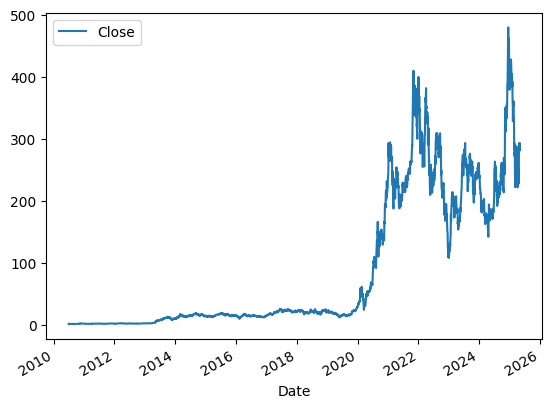

In [37]:
tesla_history.plot(x="Date", y="Close")

<Axes: xlabel='Date'>

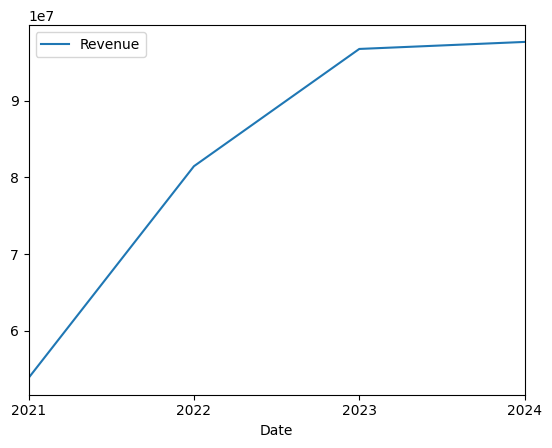

In [28]:
df_tesla_revenue.plot(x="Date", y="Revenue")

<Axes: xlabel='Date'>

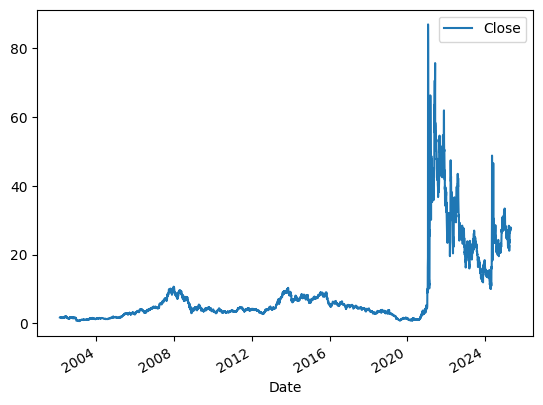

In [45]:
gamestop_history.plot(x="Date", y="Close")

<Axes: xlabel='Date'>

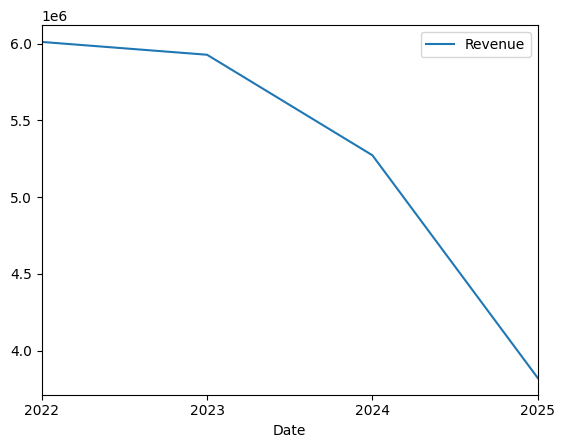

In [32]:
df_game_stop_revenue.plot(x="Date", y="Revenue")

In [38]:
tesla_history.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
3730,2025-04-28 00:00:00-04:00,288.980011,294.859985,272.420013,285.880005,151731800,0.0,0.0
3731,2025-04-29 00:00:00-04:00,285.500000,293.320007,279.470001,292.029999,108906600,0.0,0.0
3732,2025-04-30 00:00:00-04:00,279.899994,284.450012,270.779999,282.160004,128961100,0.0,0.0
3733,2025-05-01 00:00:00-04:00,280.010010,290.869995,279.809998,280.519989,99122500,0.0,0.0
3734,2025-05-02 00:00:00-04:00,285.010010,294.489990,279.809998,293.320007,76615927,0.0,0.0


In [40]:
gamestop_history.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
3730,2025-04-28 00:00:00-04:00,288.980011,294.859985,272.420013,285.880005,151731800,0.0,0.0
3731,2025-04-29 00:00:00-04:00,285.500000,293.320007,279.470001,292.029999,108906600,0.0,0.0
3732,2025-04-30 00:00:00-04:00,279.899994,284.450012,270.779999,282.160004,128961100,0.0,0.0
3733,2025-05-01 00:00:00-04:00,280.010010,290.869995,279.809998,280.519989,99122500,0.0,0.0
3734,2025-05-02 00:00:00-04:00,285.010010,294.489990,279.809998,292.915009,76448213,0.0,0.0
